In [11]:
import pandas as pd

df = pd.read_csv("dataset_tomat (1).csv")
df

,Harga,Hari,Cuaca,Promo,Total_Penjualan
0,8000,Senin,Cerah,Tidak,92
1,7500,Senin,Berawan,Tidak,88
2,12000,Selasa,Hujan,Ya,105
3,9500,Selasa,Mendung,Tidak,70
4,7000,Rabu,Cerah,Tidak,98
...,...,...,...,...,...
90,7000,Jumat,Mendung,Tidak,80
91,6500,Sabtu,Cerah,Ya,178
92,11200,Sabtu,Cerah,Tidak,130
93,11500,Minggu,Cerah,Tidak,138


In [12]:
df.shape

(95, 5)

In [13]:
df.columns

Index(['Harga', 'Hari', 'Cuaca', 'Promo', 'Total_Penjualan'], dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Harga            95 non-null     int64 
 1   Hari             95 non-null     object
 2   Cuaca            95 non-null     object
 3   Promo            95 non-null     object
 4   Total_Penjualan  95 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 3.8+ KB


In [86]:
df.isna().sum()

Harga              0
Hari               0
Cuaca              0
Promo              0
Total_Penjualan    0
dtype: int64

In [87]:
df.describe()

,Harga,Total_Penjualan
count,95.000000,95.000000
mean,9217.894737,110.810526
std,1771.042423,29.813711
min,6200.000000,60.000000
25%,7800.000000,88.000000
50%,9000.000000,102.000000
75%,10650.000000,135.000000
max,13000.000000,178.000000


In [16]:
df.head()

,Harga,Hari,Cuaca,Promo,Total_Penjualan
0,8000,Senin,Cerah,Tidak,92
1,7500,Senin,Berawan,Tidak,88
2,12000,Selasa,Hujan,Ya,105
3,9500,Selasa,Mendung,Tidak,70
4,7000,Rabu,Cerah,Tidak,98


In [17]:
df.describe()

,Harga,Total_Penjualan
count,95.000000,95.000000
mean,9217.894737,110.810526
std,1771.042423,29.813711
min,6200.000000,60.000000
25%,7800.000000,88.000000
50%,9000.000000,102.000000
75%,10650.000000,135.000000
max,13000.000000,178.000000


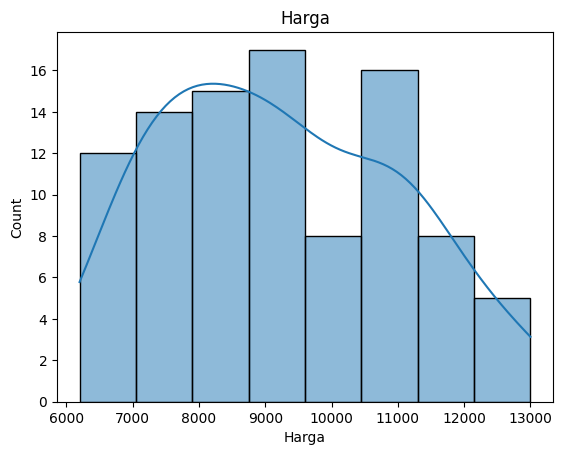

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["Harga"], kde="True")
plt.title("Harga")
plt.show()

In [25]:
skew_val = df["Harga"].skew()
print(skew_val)

0.28943257774436654


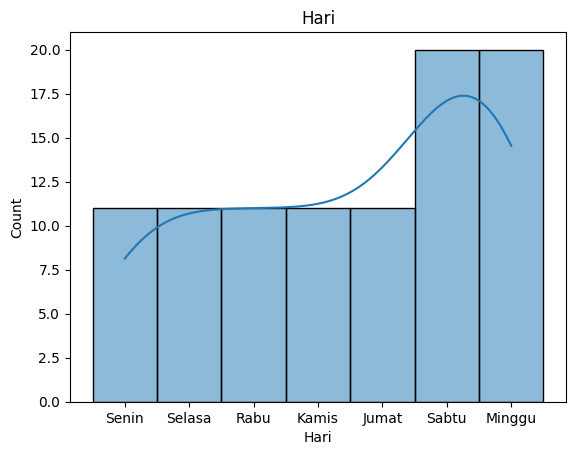

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["Hari"], kde="True")
plt.title("Hari")
plt.show()

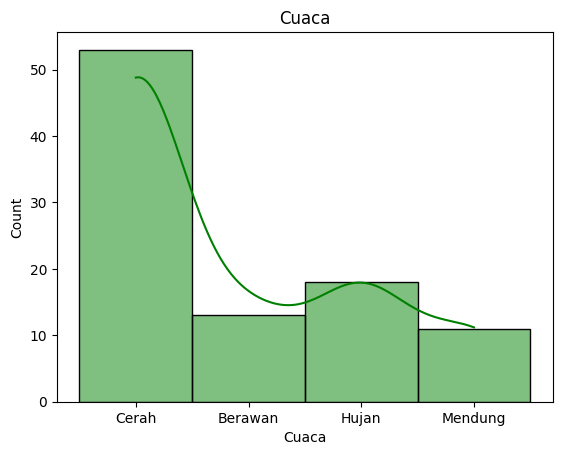

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["Cuaca"], kde="True", color="green")
plt.title("Cuaca")
plt.show()

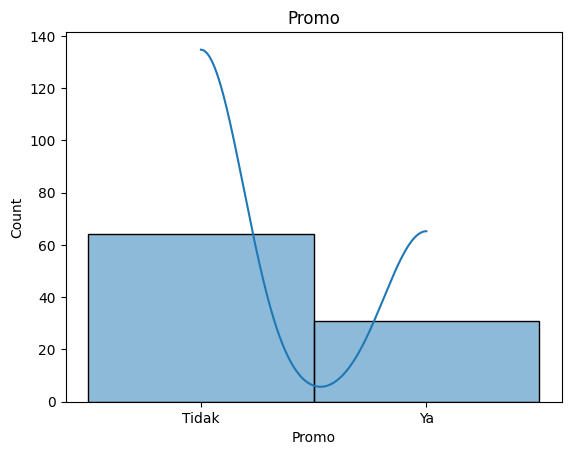

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["Promo"], kde="True")
plt.title("Promo")
plt.show()

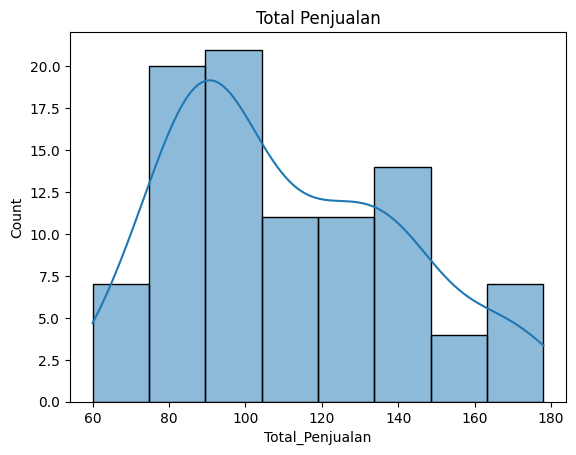

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["Total_Penjualan"], kde="True")
plt.title("Total Penjualan")
plt.show()

In [28]:
skew_val = df["Total_Penjualan"].skew()
print(skew_val)

0.5096115848504608


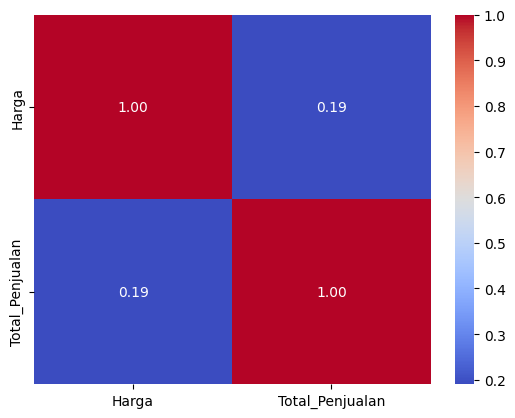

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

kolom_angka = df[["Harga", "Total_Penjualan"]]
corr = kolom_angka.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [59]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

X = df[["Harga", "Hari", "Cuaca", "Promo"]]
y = df["Total_Penjualan"]

X_train, X_test, y_train, y_test= train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_columns = ["Harga"]
categorical_columns = ["Hari", "Cuaca", "Promo"]

preprocessing = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), numeric_columns),
        ("ohe", OneHotEncoder(), categorical_columns)
    ]
)

model_linear = Pipeline(
    steps=[
        ("preprocessing", preprocessing),
        ("model", LinearRegression())
    ]
)

model_linear.fit(X_train, y_train)
y_pred = model_linear.predict(X_test)

print("R2 Score: ", r2_score(y_test,y_pred))
print("MAE : ", mean_absolute_error(y_test,y_pred))
print("MSE : ", mean_squared_error(y_test,y_pred))

R2 Score:  0.9064850021518649
MAE :  8.17094197677559
MSE :  108.13545900754994


In [77]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

X = df[["Harga", "Hari", "Cuaca", "Promo"]]
y = df["Total_Penjualan"]

X_train, X_test, y_train, y_test= train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_columns = ["Harga"]
categorical_columns = ["Hari", "Cuaca", "Promo"]

preprocessing = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), numeric_columns),
        ("ohe", OneHotEncoder(), categorical_columns)
    ]
)

model_decision = Pipeline(
    steps=[
        ("preprocessing", preprocessing),
        ("model", DecisionTreeRegressor(random_state=42, max_depth=6)) 
    ]
)

model_decision.fit(X_train, y_train)
y_pred = model_decision.predict(X_test)

print("R2 Score: ", r2_score(y_test,y_pred))
print("MAE : ", mean_absolute_error(y_test,y_pred))
print("MSE : ", mean_squared_error(y_test,y_pred))

R2 Score:  0.8056833077807589
MAE :  9.463157894736844
MSE :  224.69684210526316


In [79]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

X = df[["Harga", "Hari", "Cuaca", "Promo"]]
y = df["Total_Penjualan"]

X_train, X_test, y_train, y_test= train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_columns = ["Harga"]
categorical_columns = ["Hari", "Cuaca", "Promo"]

preprocessing = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), numeric_columns),
        ("ohe", OneHotEncoder(), categorical_columns)
    ]
)

model_random = Pipeline(
    steps=[
        ("preprocessing", preprocessing),
        ("model", RandomForestRegressor(random_state=42, max_depth=6))
    ]
)

model_random.fit(X_train, y_train)
y_pred = model_random.predict(X_test)

print("R2 Score: ", r2_score(y_test,y_pred))
print("MAE : ", mean_absolute_error(y_test,y_pred))
print("MSE : ", mean_squared_error(y_test,y_pred))

R2 Score:  0.9560047462882524
MAE :  5.137646580891024
MSE :  50.87362523388349


In [80]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model_random, X_train, y_train, cv=5, scoring="r2")
print("Scores : ", scores)
print("Mean Scores : ", scores.mean())

Scores :  [0.90913251 0.94418754 0.80803734 0.93681458 0.91498963]
Mean Scores :  0.9026323194235084


In [88]:
import joblib

joblib.dump(model_random, "model_random.joblib")

['model_random.joblib']

In [89]:
import pandas as pd
import joblib

model_random = joblib.load("model_forest.joblib")
data_baru = pd.DataFrame([[5000, "Selasa", "Hujan", "Tidak"]],
                         columns=["Harga", "Hari", "Cuaca", "Promo"])
prediksi = model_random.predict(data_baru)[0]
print(f"Model memprediksi total penjualan {prediksi:.0f}")

Model memprediksi total penjualan 82
